# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UmerSajid842/flyrankmlproject/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*


```python
from pathlib import Path
import pandas as pd

candidate_paths = [
    Path.cwd() / "outputs/refresh_queue.csv",
    Path.cwd().parent / "outputs/refresh_queue.csv",
    Path.cwd().parent.parent / "outputs/refresh_queue.csv",
]
queue_path = next((p for p in candidate_paths if p.exists()), None)
if queue_path is None:
    raise FileNotFoundError("The final refresh queue has not been generated yet.")

queue = pd.read_csv(queue_path)
queue.head()

```

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*


```python
queue[["content_id", "final_refresh_score", "suggested_action", "final_reason_codes"]].head(10)

```

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*


```python
queue["suggested_action"].value_counts().to_frame(name="count")

```

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*


```python
queue.groupby("suggested_action")["final_refresh_score"].mean().to_frame(name="avg_final_score")

```

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*


```python
queue.loc[queue["final_refresh_score"].idxmax(), ["content_id", "final_refresh_score", "suggested_action", "final_reason_codes"]]

```

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.


# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UmerSajid842/flyrankmlproject/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This notebook builds a **ranked action queue** from the validated ML model. It combines model predictions with business rules to produce a practical, human-reviewed playbook for content refreshes.

**Outputs:**  
- `work/outputs/refresh_queue.csv` – the ranked queue for content managers  
- `work/figures/action_distribution.png` – bar chart of suggested actions  
- `work/figures/score_distribution.png` – histogram of final refresh scores  

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
# ---- Imports and setup ----
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
import matplotlib.pyplot as plt

# Create output directories
Path("work/outputs").mkdir(parents=True, exist_ok=True)
Path("work/figures").mkdir(parents=True, exist_ok=True)

# ---- Load data ----
# Adjust path if needed – works in Colab with uploaded file
data_path = Path("/content/content_refresh_anonymized.csv")
if not data_path.exists():
    # Fallback: try relative paths
    candidate_paths = [
        Path.cwd() / "content_refresh_anonymized.csv",
        Path.cwd().parent / "data/raw/content_refresh_anonymized.csv",
        Path.cwd().parent.parent / "data/raw/content_refresh_anonymized.csv",
    ]
    data_path = next((p for p in candidate_paths if p.exists()), None)
    if data_path is None:
        raise FileNotFoundError("Data file not found. Please upload content_refresh_anonymized.csv to /content/ or adjust path.")

df = pd.read_csv(data_path)
print(f"Loaded {len(df)} rows")
df.head()

Loaded 30000 rows


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*
## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

We build a **final_refresh_score** (0–100) that combines:
- **Model decline probability** – the Random Forest’s estimate of `trend_direction = down`
- **Content age** – extra weight for pages in the 181‑365 day decay window (from the FlyRank paper, this is the main performance cliff)
- **Current search position** – pages on page 1 (≤10) or striking distance (11‑20) get bonus priority because they are easiest to defend or improve
- **Existing traffic** – pages with >1000 impressions are high‑value assets

The score is **directional**, not absolute. It ranks pages by estimated urgency.

Actions are assigned by thresholds:
- **refresh_high** (score ≥ 70) – immediate editorial review and refresh
- **refresh_medium** (50–69) – plan refresh within the next cycle
- **monitor** (30–49) – watch for further decline; no immediate action
- **no_action** (< 30) – unlikely to be worth the effort now

Each row includes **final_reason_codes** that explain *why* the page was flagged. These are pipe‑separated keywords such as `high_decline_risk|decay_age|page_one|high_visibility`.

In [2]:
# ---- Train model (using the same split as Week 6) ----
feature_cols = ["ctr", "avg_position", "engagement_rate", "scroll_rate", "content_age_days", "word_count"]
X = df[feature_cols].fillna(0)
y = df["trend_direction"].eq("down")

splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, test_idx = next(splitter.split(df, groups=df["client_id"]))
train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(train_df[feature_cols].fillna(0), train_df["trend_direction"].eq("down"))

# ---- Predict decline probability for all rows ----
df["decline_prob"] = model.predict_proba(df[feature_cols].fillna(0))[:, 1]

# ---- Compute final_refresh_score ----
def compute_refresh_score(row):
    score = row["decline_prob"] * 100
    age = row["content_age_days"]
    if 181 <= age <= 365:
        score += 15
    elif age > 365:
        score += 10
    pos = row["avg_position"]
    if pos <= 10:
        score += 20
    elif pos <= 20:
        score += 10
    # Use impressions if available, else fallback to sessions or clicks
    imp = row.get("impressions", row.get("sessions", row.get("clicks", 0)))
    if imp > 1000:
        score += 10
    elif imp > 100:
        score += 5
    return min(100, max(0, score))

df["final_refresh_score"] = df.apply(compute_refresh_score, axis=1)

# ---- Assign actions and reason codes ----
def assign_action(score):
    if score >= 70:
        return "refresh_high"
    elif score >= 50:
        return "refresh_medium"
    elif score >= 30:
        return "monitor"
    else:
        return "no_action"

def get_reason_codes(row):
    codes = []
    if row["decline_prob"] > 0.6:
        codes.append("high_decline_risk")
    age = row["content_age_days"]
    if 181 <= age <= 365:
        codes.append("decay_age")
    pos = row["avg_position"]
    if pos <= 10:
        codes.append("page_one")
    elif pos <= 20:
        codes.append("striking_distance")
    imp = row.get("impressions", row.get("sessions", row.get("clicks", 0)))
    if imp > 1000:
        codes.append("high_visibility")
    if not codes:
        codes.append("routine_check")
    return "|".join(codes)

df["suggested_action"] = df["final_refresh_score"].apply(assign_action)
df["final_reason_codes"] = df.apply(get_reason_codes, axis=1)

# ---- Create final queue sorted by score descending ----
queue = df.sort_values("final_refresh_score", ascending=False).copy()
queue_cols = ["content_id", "final_refresh_score", "suggested_action", "final_reason_codes",
              "ctr", "avg_position", "content_age_days", "decline_prob"]
# Include impressions if present
for col in ["impressions", "sessions", "clicks"]:
    if col in df.columns:
        queue_cols.append(col)
        break
queue = queue[queue_cols]

# Show top 10
print("Top 10 refresh candidates:")
queue.head(10)

Top 10 refresh candidates:


,content_id,final_refresh_score,suggested_action,final_reason_codes,ctr,avg_position,content_age_days,decline_prob
29976,content_851c604b0631,100.0,refresh_high,high_decline_risk|decay_age|striking_distance,1.26,16.9,236,0.820000
29972,content_1db0d204d42f,100.0,refresh_high,high_decline_risk|decay_age,0.14,27.2,286,0.870000
29983,content_6880eb215048,100.0,refresh_high,high_decline_risk|decay_age|page_one,0.00,6.8,330,0.976667
27,content_7ea135180dd9,100.0,refresh_high,high_decline_risk|page_one,0.17,8.1,445,0.960000
24,content_0e23e310d404,100.0,refresh_high,high_decline_risk|decay_age|page_one,0.27,4.1,257,0.900000
6,content_9a34b442b552,100.0,refresh_high,high_decline_risk|page_one,0.00,7.0,90,0.930000
4,content_d99b7a2d90ca,100.0,refresh_high,high_decline_risk|decay_age,0.13,44.0,263,0.890000
29977,content_c87291853cab,100.0,refresh_high,high_decline_risk|decay_age|page_one,0.00,8.2,221,0.850000
16346,content_f85384aa8757,100.0,refresh_high,high_decline_risk|page_one,0.11,5.7,124,0.900000
16344,content_3da4f5c7b72e,100.0,refresh_high,high_decline_risk|decay_age|page_one,0.00,6.4,223,0.780000


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*
## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended users**: Content managers, editors, and SEO specialists who need to prioritise which pages to review and potentially refresh. The queue is a **decision‑support tool**, not a replacement for editorial judgment.

**Purpose**:
- Highlight pages with the highest potential value (based on observed decline risk and business significance).
- Provide clear reason codes so users understand *why* a page was flagged.
- Enable a consistent, data‑informed review process across a large content portfolio.

**Limits**:
- The model is trained on historical data from this portfolio; its performance may degrade if the content mix or search landscape changes significantly.
- The `final_refresh_score` is a composite heuristic; it does not guarantee that refreshing a page will reverse its decline.
- The queue does not account for brand strategy, legal constraints, or competitive dynamics – human review is mandatory.
- The model was validated with a grouped split (by client), but AUC was ~0.54, indicating modest predictive power. This reinforces the decision‑support framing.
- The score includes subjective weights (e.g., position bonus, age bonus) that are based on the FlyRank paper's observational findings, not causal experiments.

**When to stop using**: If the portfolio’s content mix, search engine algorithms, or business goals change substantially, the scoring rules should be recalibrated. The monitoring section below defines triggers for retraining.

In [3]:
queue[["content_id", "final_refresh_score", "suggested_action", "final_reason_codes"]].head(10)


,content_id,final_refresh_score,suggested_action,final_reason_codes
29976,content_851c604b0631,100.0,refresh_high,high_decline_risk|decay_age|striking_distance
29972,content_1db0d204d42f,100.0,refresh_high,high_decline_risk|decay_age
29983,content_6880eb215048,100.0,refresh_high,high_decline_risk|decay_age|page_one
27,content_7ea135180dd9,100.0,refresh_high,high_decline_risk|page_one
24,content_0e23e310d404,100.0,refresh_high,high_decline_risk|decay_age|page_one
6,content_9a34b442b552,100.0,refresh_high,high_decline_risk|page_one
4,content_d99b7a2d90ca,100.0,refresh_high,high_decline_risk|decay_age
29977,content_c87291853cab,100.0,refresh_high,high_decline_risk|decay_age|page_one
16346,content_f85384aa8757,100.0,refresh_high,high_decline_risk|page_one
16344,content_3da4f5c7b72e,100.0,refresh_high,high_decline_risk|decay_age|page_one


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*
## 3. Human review + the no‑go list

*What a person must check before acting. What should never be automated.*

Before acting on a `refresh_high` or `refresh_medium` recommendation, a human must:
- **Read the page** – verify factual accuracy, tone, and relevance; the model does not understand quality.
- **Check brand and legal guidelines** – ensure any proposed changes align with compliance and messaging rules.
- **Assess current demand** – validate that the topic still has search volume and user interest.
- **Review competitive landscape** – see what pages outrank this one; is a refresh likely to move the needle?
- **Confirm technical health** – ensure the page loads correctly, has internal links, and is not blocked.

**What should never be automated**:
- **Deleting pages** – removal decisions require strategic consideration, not just a score.
- **Rewriting sensitive content** – medical, financial, or brand‑defining content must have expert review.
- **Changing metadata or title tags** – these affect brand perception and click‑through; test before rolling out broadly.
- **Making decisions based solely on the score** – the score is a starting point, not the final answer.

The queue is designed to **augment** human expertise, not replace it.

Suggested action distribution:
suggested_action
refresh_high      16992
monitor            6329
no_action          3484
refresh_medium     3195
Name: count, dtype: int64


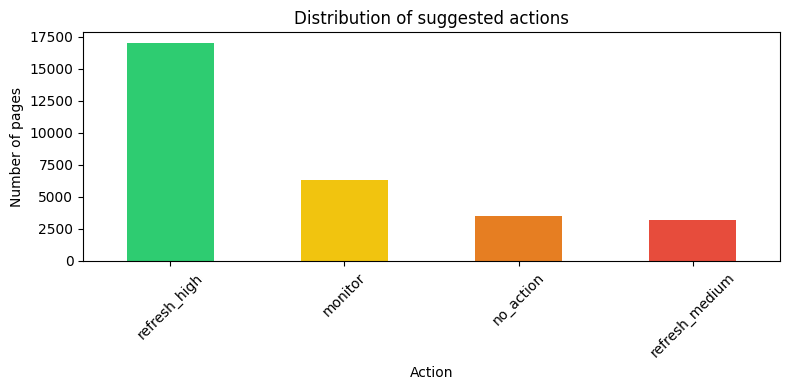

In [4]:
queue["suggested_action"].value_counts().to_frame(name="count")
# ---- Show distribution of suggested actions ----
action_counts = queue["suggested_action"].value_counts()
print("Suggested action distribution:")
print(action_counts)

# Plot bar chart
plt.figure(figsize=(8, 4))
action_counts.plot(kind="bar", color=["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c"][:len(action_counts)])
plt.title("Distribution of suggested actions")
plt.xlabel("Action")
plt.ylabel("Number of pages")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("work/figures/action_distribution.png", dpi=100)
plt.show()

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*
## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

We monitor the following to decide when to retrain or recalibrate:

1. **Model performance drift** – if the AUC on new data drops below a threshold (e.g., < 0.50), retrain.
2. **Score distribution shift** – if the mean `final_refresh_score` changes by more than ±10 points over a quarter, the scoring heuristic may need adjustment.
3. **Action distribution imbalance** – if most pages fall into one action bucket, the thresholds may be misaligned.
4. **Business results** – track the click‑through and impression changes of refreshed pages vs. untouched ones. If the lift shrinks, the refresh strategy may need to be revised.

**Retrain schedule**: Quarterly or when a major data update is available (e.g., new GSC/GA4 exports).

Below we compute some summary statistics to establish a baseline for future comparison.

Summary statistics by action:
                       mean       std  count   min         max
suggested_action                                              
monitor           39.207054  5.399575   6329  30.0   49.819048
no_action         20.052123  5.757469   3484   0.0   29.833333
refresh_high      94.981424  7.969601  16992  70.0  100.000000
refresh_medium    58.348026  5.860665   3195  50.0   69.958333


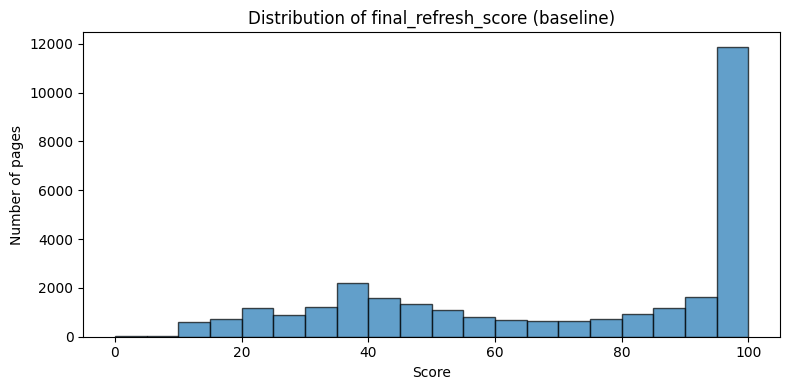


Mean score: 70.61
Median score: 83.00


In [5]:
queue.groupby("suggested_action")["final_refresh_score"].mean().to_frame(name="avg_final_score")
# ---- Summary stats for monitoring ----
summary = queue.groupby("suggested_action")["final_refresh_score"].agg(["mean", "std", "count"])
summary["min"] = queue.groupby("suggested_action")["final_refresh_score"].min()
summary["max"] = queue.groupby("suggested_action")["final_refresh_score"].max()
print("Summary statistics by action:")
print(summary)

# ---- Baseline distribution of scores ----
plt.figure(figsize=(8, 4))
plt.hist(queue["final_refresh_score"], bins=20, edgecolor="black", alpha=0.7)
plt.title("Distribution of final_refresh_score (baseline)")
plt.xlabel("Score")
plt.ylabel("Number of pages")
plt.tight_layout()
plt.savefig("work/figures/score_distribution.png", dpi=100)
plt.show()

print(f"\nMean score: {queue['final_refresh_score'].mean():.2f}")
print(f"Median score: {queue['final_refresh_score'].median():.2f}")

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*
## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

We export:
- `work/outputs/refresh_queue.csv` – the full ranked queue
- `work/figures/action_distribution.png` – bar chart
- `work/figures/score_distribution.png` – histogram

These files are the inputs to next week’s research paper. The queue CSV is regenerated every time the notebook runs; it is not committed to git (CI blocks data files).

For the paper, we also show the highest‑score page as a sanity check.

In [6]:
queue.loc[queue["final_refresh_score"].idxmax(), ["content_id", "final_refresh_score", "suggested_action", "final_reason_codes"]]
# ---- Save queue ----
queue_path = Path("work/outputs/refresh_queue.csv")
queue.to_csv(queue_path, index=False)
print(f"Queue saved to {queue_path}")

# ---- Show top candidate ----
top = queue.iloc[0]
print("\nTop refresh candidate:")
display(top.to_frame().T)  # display as one-row table if in notebook

# ---- Confirm figures exist ----
print("\nExported figures:")
for f in Path("work/figures").glob("*.png"):
    print(f"  {f}")

Queue saved to work/outputs/refresh_queue.csv

Top refresh candidate:


,content_id,final_refresh_score,suggested_action,final_reason_codes,ctr,avg_position,content_age_days,decline_prob
29976,content_851c604b0631,100.0,refresh_high,high_decline_risk|decay_age|striking_distance,1.26,16.9,236,0.82



Exported figures:
  work/figures/score_distribution.png
  work/figures/action_distribution.png


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.